In [1]:
#import packages. 
#Note that if you get an error when importing saphires that certain packages are not found, 
#you'll need to pip install them as well
import numpy as np
import os
from scipy.optimize import curve_fit
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pickle as pkl
from scipy.ndimage import gaussian_filter
import scipy
%matplotlib inline 

In [2]:
star = 'HD57267'#"29Dra"
path = r'C:\Users\astro\SSGs\stars\\' + star + '\\'#r"D:\SSGs\stars\\" + star + '\\'
spec_path = r'C:\Users\astro\SSG_Spectra\H-alpha_Analysis'
datfile = path + star + "_coude_head.dat"
image_path = spec_path + '\General_Spectral_Analysis\Spectral_Images\\'
RV_file =  r'C:\Users\astro\SSGs\starstxt4' + '\\' + star + '\\' #Data3\starstxt3' + '\\' + star + '.txt' #r'D:\SSGs\Data3\starstxt3' + '\\' + star + '.txt'

Ha_file = spec_path + "\Analyze_Spectra\Analyze_" + star + ".txt"
CaH_file = spec_path + '\Analyze_CaH\CaH_Analyze_' + star + '.txt'
CaK_file = spec_path + '\Analyze_CaH\CaK_Analyze_' + star + '.txt'

#Constants
R_coude = 60000.0 #spectral resolution of the Coude. 
c = (2.9979245*10**5) #speed of light

# Functions

In [3]:
#Functions 

#File Finder
def fitfile_open(file_name):
    with open(file_name, 'r') as file:
        fit_data = [line.strip().split("/") for line in file]
    
    dat_type = fit_data[0]
    del fit_data[0]
    return fit_data, dat_type

#Returns Guesses, parameters 
def guess_find(fit_dat, print_dates = False):
    guess = [np.array(temp[7].strip('[]').split(","), dtype = float) for temp in fit_dat]
    lims = [np.array(res[6].strip('[]').split(","), dtype = float) for res in fit_dat]
    date_line = [day[1] for day in fit_dat]

    if print_dates == True:
        return lims, guess, date_line
    else:
        return lims, guess

#Wavelength to velocity conversion
def velocity_spec(wav, bvcorr, lam, rv=0):
    v_spec = ((wav-lam)/lam)*c + bvcorr + (bvcorr/c) - rv
    return v_spec

def vel_to_wav(vel, bvcorr, lam):
    l_vel = lam * ((vel - bvcorr)/c + 1)
    return l_vel


#Filters wavelengths to certain points
def filterer(region, bounds, spect):
    spec_where = np.where((spect['wav'][region]>bounds[0]) & (spect['wav'][region]<bounds[1]))
    tempList_wavelength = spect['wav'][region][spec_where]
    tempList_flux = spect['flux'][region][spec_where]
    
    return  tempList_flux,  tempList_wavelength

#Adjust boundaries of spectrum
def adjust_bounds(arr, arr2, bounds):
    filt_where = np.where((arr > bounds[0]) & (arr < bounds[1]))
    tempList_wav = arr[filt_where]
    tempList_flux2 = arr2[filt_where]
    return tempList_flux2, tempList_wav

def gauss(x, *p): 
    A, mu, sigma, B = p
    y = A * np.exp(-((x - mu)**2)/(2 * sigma ** 2 )) + B
    return y

def integrate(popt):
    upperlam = popt[1]+2
    lowerlam = popt[1]-2
    IntHa2 = scipy.integrate.quad(gauss, lowerlam, upperlam, args = (popt[0], popt[1], popt[2],popt[3]))
    Int1 = (upperlam - lowerlam)
    B = popt[3]
    Int2 = IntHa[0]/B
    IntHA = Int1-Int2
    return IntHA


# Load Files Here

In [4]:
#Removes 1st row    

In [6]:
#General Star Info
with open(RV_file + star + '.txt', 'r') as file:
    rv_overview_data = file.readlines()
#rv data
with open(RV_file + star + '_RVs.txt', 'r') as file:
    dat_RV = file.readlines()
    
with open(RV_file + star + '_vsini.txt', 'r') as file:
    dat_vsini = file.readlines()   

rv_data = [k.strip(',\n').strip('[]').strip("\"\"").strip(']').split(',') for k in dat_RV]
vsini_data = [k.strip(',\n').strip('[]').strip("\"\"").strip(']').split(',') for k in dat_vsini]

#Coude Data
with open(datfile, 'r') as file:
    datfile_data = [line.strip().split(",") for line in file]
del datfile_data[0]  

#Opens ha fit parameters
#ha_data, ha_datTypes = fitfile_open(Ha_file)
#CaH_data, CaH_datTypes = fitfile_open(CaH_file)
#CaK_data, CaK_datTypes = fitfile_open(CaK_file)


In [7]:
print('Is there bad/Missing data: ', len(rv_data) != len(datfile_data))
for i in range(len(rv_data)):
    print(i, datfile_data[i][5], rv_data[i][0])

Is there bad/Missing data:  False
0 2459174.9894228578 2459174.98942
1 2459305.6867321976 2459305.68673


In [8]:

#remove Files here
'''
for i in [10]:
    del datfile_data[i]
    #del rv_data[i]
'''

'\nfor i in [10]:\n    del datfile_data[i]\n    #del rv_data[i]\n'

In [9]:
for i in range(len(datfile_data)):
    print(i, datfile_data[i][0])

0 HD57267_2020-11-21_0.pkl
1 HD57267_2021-04-01_0.pkl


In [10]:
data = np.array(datfile_data)
#Number of files
numFiles = len(data)
files = data[:,0]

In [11]:
#Loading Files
specs = []

for i in range(len(files)):
    file1 = path + files[i]
    spec = pkl.load(open(file1, 'rb'))
    specs.append(spec)


# Gather Data Here

In [12]:
specs[0].keys()

print(specs[0].keys)

<built-in method keys of dict object at 0x0000020957078A80>


for i in range(specs[0]['wav'].shape[0]):
    print(i,specs[0]['wav'][i,0],spec['wav'][i,-1])

In [13]:
#-----------------------------------------------------Spectral Lines
#H-alpha
o_ha = 39
l_ha= 6562.8

l_CaH = 3968.47
o_CaH = 5

l_CaK = 3933.66
o_CaK = 4

o_hb = 20
l_hb = 4861.35

o_hy = 12
l_hy = 4340.472

o_Hd = 7
l_Hd = 4101.75

o_li = 40
l_li= 6707.8

#------------------------------------------BVCORRs, BJDs, dates from coude header data
BVCORRs = np.array(data[:,6], float)
BJDs = np.array(data[:,5], float)
date = [s.split('_')[1] for s in files]
lins = [s.split('_')[2] for s in files]

#AV_RV and RV_STD
av_RV = float(rv_overview_data[5].split(' ')[-2])
RV_STD = float(rv_overview_data[6].split(' ')[-2])
print('Average RV: ', av_RV, '\t', 'RV STDEV:', RV_STD)

#RVs and Vsinis

RVs = [float(rad_vel[1]) for rad_vel in rv_data]
vsinis = [float(vsini[1]) for vsini in vsini_data]

#Fitting Data
#lims_ha, guesses_ha, ha_dates = guess_find(ha_data, True) #Needed For H-alpha Fits
#lims_CaH, guesses_CaH = guess_find(CaH_data)
#lims_CaK, guesses_CaK = guess_find(CaK_data)

print(vsinis)


Average RV:  37.371 	 RV STDEV: 38.859
[34.749, 35.133]


# Sort Index By Radial Velocity

In [14]:
num_figs = int(np.ceil(len(date)/2))
print('number of figures', num_figs, len(date))

RVs_list1 = list(RVs)
rvs_index = []
for i in range(len(date)):
    maximum = max(RVs_list1)
    maxi = RVs.index(maximum)
    rvs_index.append(maxi)
    print(maxi, date[maxi], RVs[maxi])
    RVs_list1 = np.delete(RVs_list1, int(RVs_list1.index(maximum)))
    RVs_list1 = list(RVs_list1)

number of figures 1 2
0 2020-11-21 76.23
1 2021-04-01 -1.488


# Spectral Images

In [23]:
def plt_spec(spect, index, l_spec, o_spec, lims, guesses, ax_name, 
              l_col = 'r', lsec_col = 'b', CoM_col = 'm', spec_col = 'tab:blue', gauss_col = 'tab:orange',
              xlims = [None, None], ylims = [None, None], 
             line_class = None, RV_Mode = True, plt_gauss = False, plt_sec = False):
    
    #Fits Gaussian
    flux, wavelength = filterer(o_spec, lims, spect)
    if (plt_gauss == True):
        popt, pcov = scipy.optimize.curve_fit(gauss, wavelength, flux, guesses)
        fit_flux = gauss(wavelength, popt[0], popt[1], popt[2], popt[3])
    else:
        plt_gauss = False

    if RV_Mode == False:
        v_spec = wavelength
        com_rv = vel_to_wav(av_RV, BVCORRs[index], l_spec)
        low_vsini = vel_to_wav(RVs[index] - vsinis[index], BVCORRs[index], l_spec) 
        hi_vsini = vel_to_wav(RVs[index] + vsinis[index], BVCORRs[index], l_spec)
        prim_rv  = vel_to_wav(RVs[index], BVCORRs[index], l_spec)
        x_label = 'Wavelength (A)'
    else:
        v_spec = velocity_spec(wavelength, BVCORRs[index], l_spec, rv=0)
        com_rv = av_RV
        low_vsini = RVs[index] - vsinis[index]
        hi_vsini = RVs[index] + vsinis[index]
        prim_rv  =  RVs[index]
        x_label  = 'Barycentric Radial Velocity (km/s)'
    
    #Colors
    l_col = l_col
    CoM_col = CoM_col
    spec_col = spec_col
    lsec_col = lsec_col
    gauss_col = gauss_col
    
    #xlim and ylims
    xlim1, xlim2 = xlims
    ylim1, ylim2  = ylims
    
    #sets Title
    if line_class == None:
        fig_title = date[index]
    else:
        fig_title = date[index] + " (" + str(line_class) + ")"

  
    #Plot
    ax_name.set_title(fig_title, fontsize = 24)
        #Shaded Region
    ax_name.axvline(low_vsini, color = l_col, ls = "--", alpha = 0.3)
    ax_name.axvline(hi_vsini, color = l_col, ls = "--", alpha = 0.3)
    ax_name.axvspan(low_vsini, hi_vsini, alpha=0.3, color= l_col)
    #Fits
    ax_name.plot(v_spec, flux, 'ko', ms = 9, mec = l_col)
    ax_name.plot(v_spec, flux, color = spec_col ,lw = 3)

    if plt_gauss == True:
        ax_name.plot(v_spec, fit_flux, color = gauss_col, lw = 3)

    #Spec Lines
    ax_name.axvline(prim_rv, color = l_col, ls = '--', label ='Primary RV', lw = 4)
    ax_name.axvline(com_rv, color = CoM_col, ls = '-', label = 'CoM RV', lw = 4)

    #Set Labels
    ax_name.set_ylabel('Flux', fontsize = 24)
    ax_name.set_xlabel(x_label, fontsize = 24)
    ax_name.legend(fontsize= 24)
    ax_name.tick_params(axis='both', labelsize = 24)
    
    ax_name.set_xlim(xlim1, xlim2)
    ax_name.set_ylim(ylim1, ylim2)

In [24]:
#Color Coding
line_color =  '#b44586'
CoM_color = '#52730b'
wav_color = 'tab:blue'
fit_color = 'tab:orange'


In [47]:
def line_autoplot(l_line, o_line, line_name = '', addclasses = False, classes = [''], ran = 5):
    if num_figs < 4:
        fig_adjust = 0.90
    elif num_figs < 6:
        fig_adjust = 0.93
    else:
        fig_adjust = 0.95
    
    fig, ax = plt.subplots(num_figs, 2, figsize = (20, 7*num_figs))
    fig.suptitle(line_name + " Spectrum " + star, fontsize = 40)
    rows = 0
    num_cols = 1
    cols = 0
    
    for j in (rvs_index):
        k = 0
        if addclasses == True:
            lspec_class = classes[k]
            k = k+1
        else:
            lspec_class = None
        lshift = vel_to_wav(RVs[j], BVCORRs[j], l_line)
        line_lims = [lshift - ran, lshift + ran]
        
        print(rows, cols)
        
        plt_spec(specs[j], j, l_line, o_line, line_lims, -1, ax_name= ax[cols], 
                      l_col = line_color, CoM_col = CoM_color, spec_col = wav_color , gauss_col = fit_color,
                      xlims = [None, None], ylims= [None, None], line_class = lspec_class,
                      RV_Mode = True, plt_gauss = False, plt_sec = False);
        if (cols == num_cols):
            cols = 0
            rows = rows + 1
        else:
            cols = cols + 1
    fig.tight_layout()
    #fig.subplots_adjust(top=fig_adjust)
    return fig, ax

# H-alpha Spectra

0 0
0 1


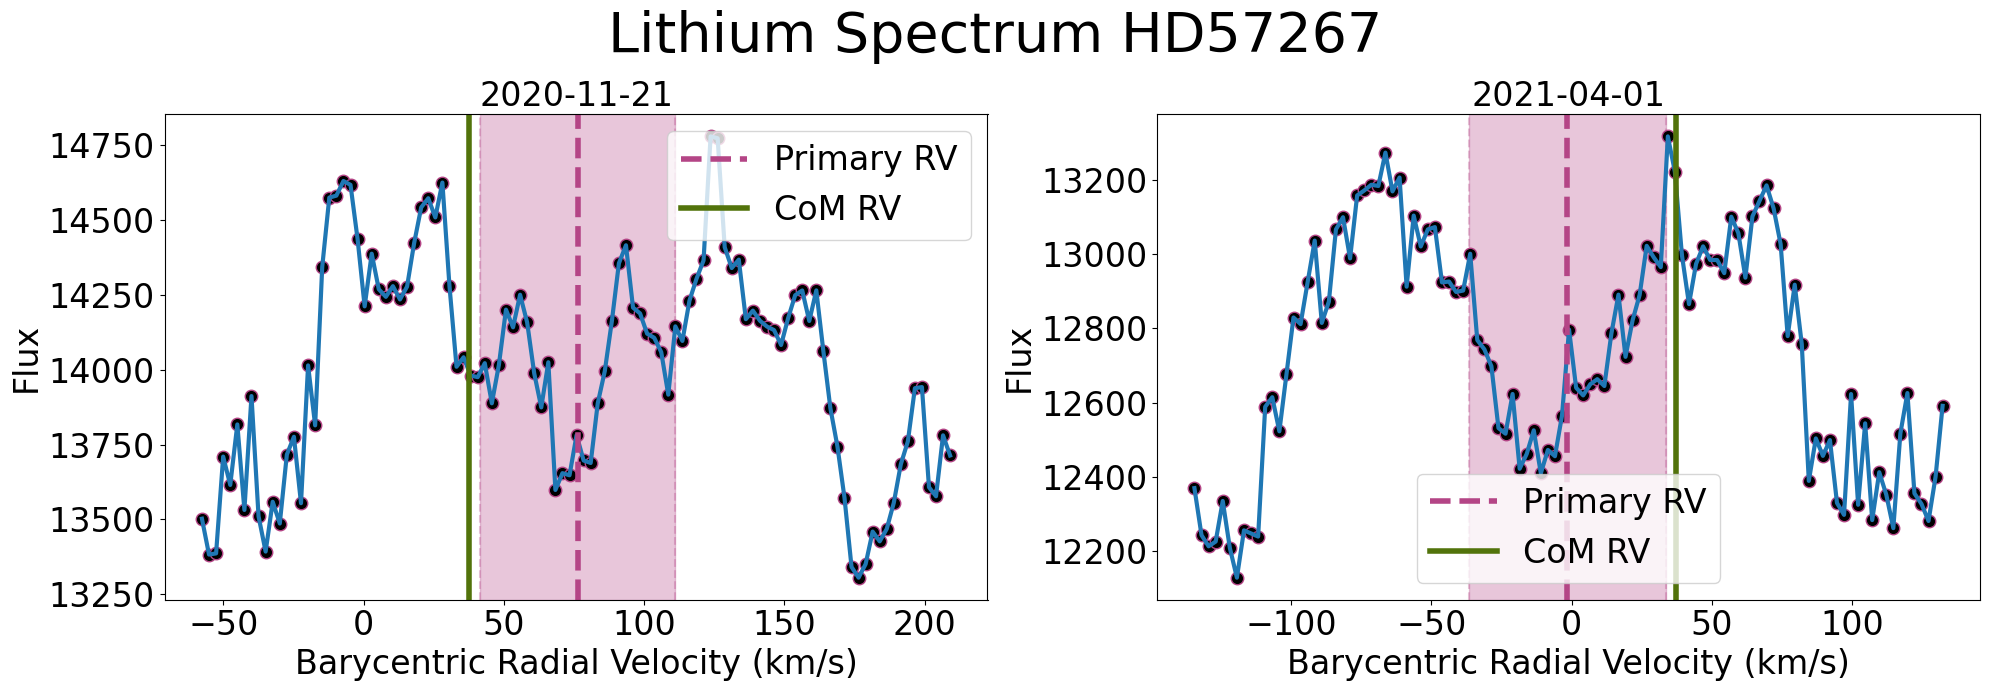

In [48]:
fig1, ax = line_autoplot(6707.8, o_li, 'Lithium', ran = 3)

0 0
0 1
Unfitted_H-alpha_RV_profiles_HD57267.png


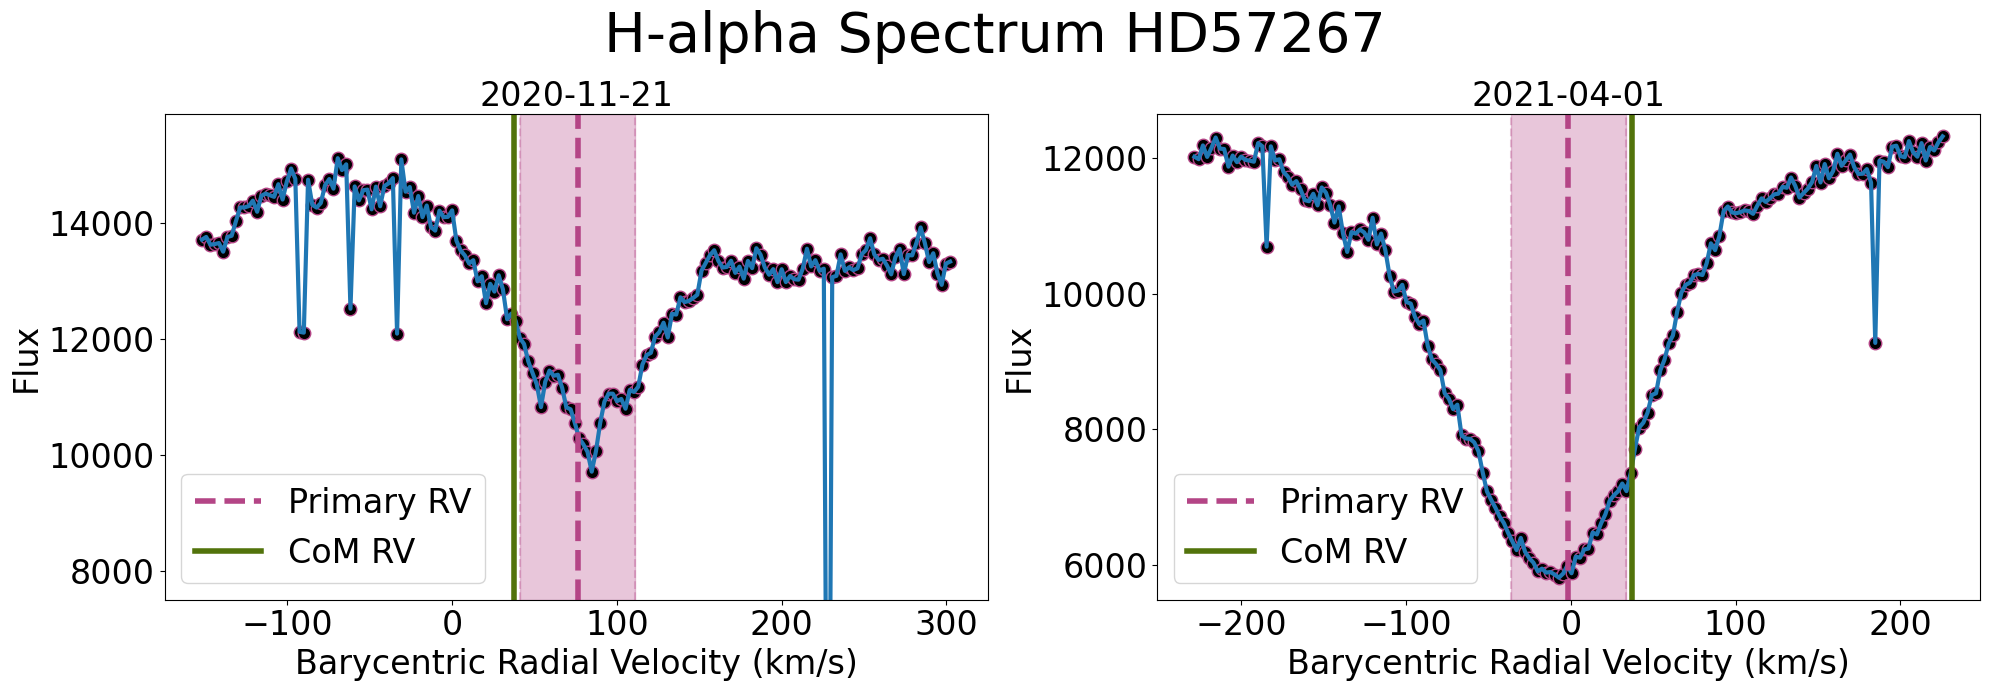

In [49]:
#plotting h_gamma
fig1, ax = line_autoplot(l_ha, o_ha, 'H-alpha', ran = 5)
#fig1.subplots_adjust(top=0.93)

#ax[0,0].set_ylim(15000)
#ax[0,1].set_ylim(750)
#ax[1,0].set_ylim(5000)
#ax[0].set_ylim(7500)
#ax[2,0].set_ylim(900)
#ax[2,1].set_ylim(350)
#ax[3,0].set_ylim(1000)
#ax[3,1].set_ylim(1500)
#ax[4,0].set_ylim(1200)
#ax[4,1].set_ylim(1500)
#ax[5,0].set_ylim(600)

ha_figName = 'Unfitted_H-alpha_RV_profiles_' + star + '.png'
print(ha_figName)
#fig1.savefig(ha_figName, dpi = 300)

# Ploting Ca H + K Lines

Ca + H

0 0
0 1


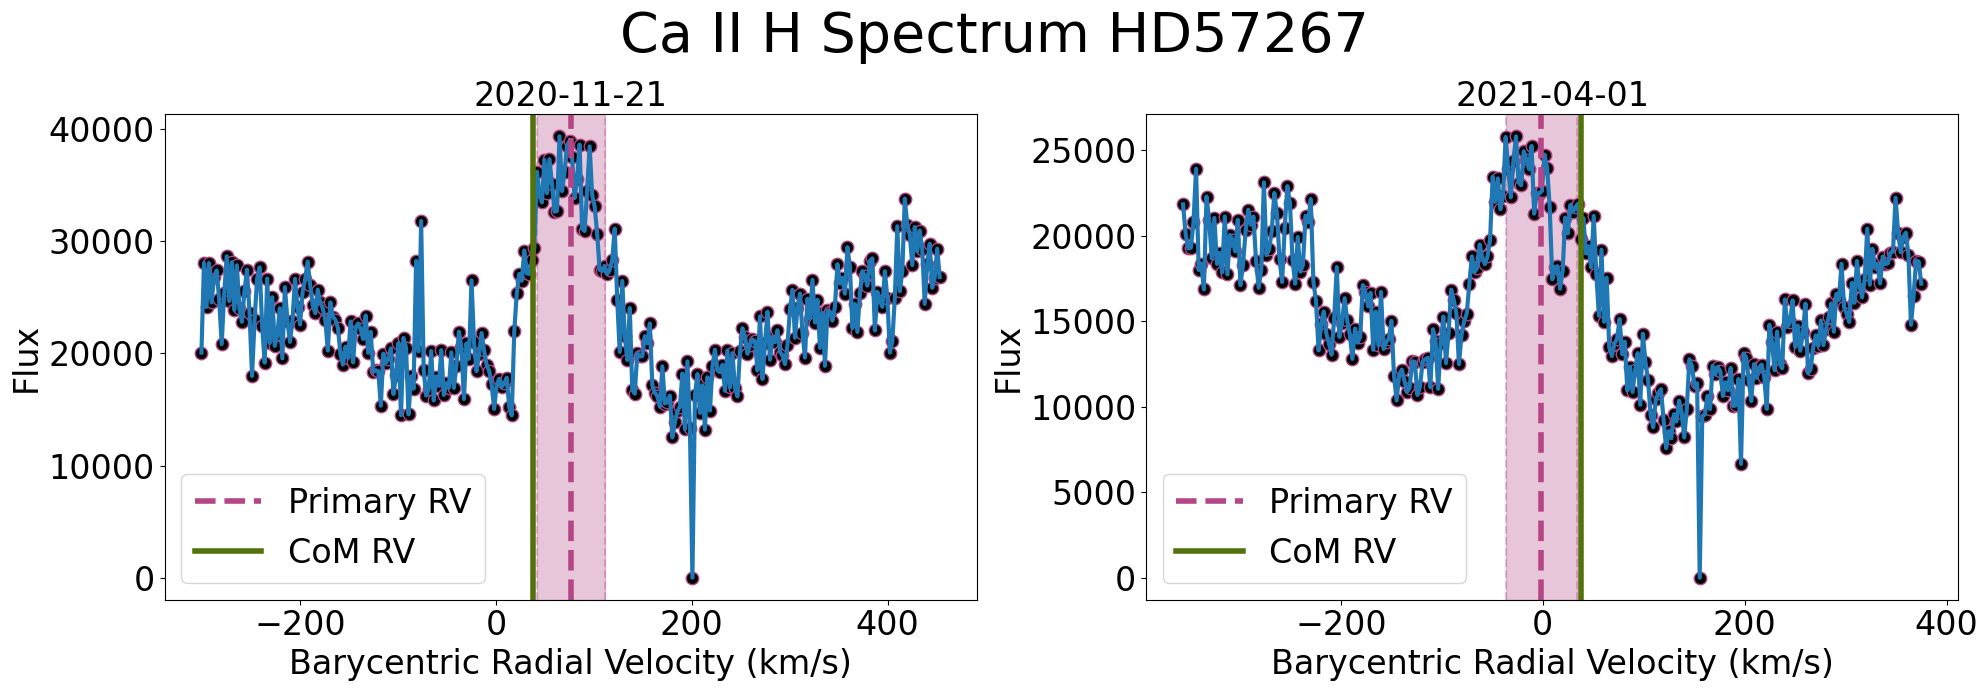

In [50]:
fig2, ax2 = line_autoplot(l_CaH, o_CaH, 'Ca II H', ran = 5)
#ax2[0,0].set_ylim(top=10000)
#ax2[1,0].set_ylim(0, 6000)
#ax2[3,0].set_ylim(top = 15000)
#ax2[5,0].set_ylim(top=4000)
#ax2[5,1].set_ylim(top=7500)
#ax2[3,0].set_ylim(top = 15000)
#ax2[4,1].set_ylim(top = 5000)

#ax2[2,0].set_ylim(top=4000)
#ax2[2,1].set_ylim(top=5000)
#ax2[3,1].set_ylim(top = 4000)

Ca+K

0 0
0 1


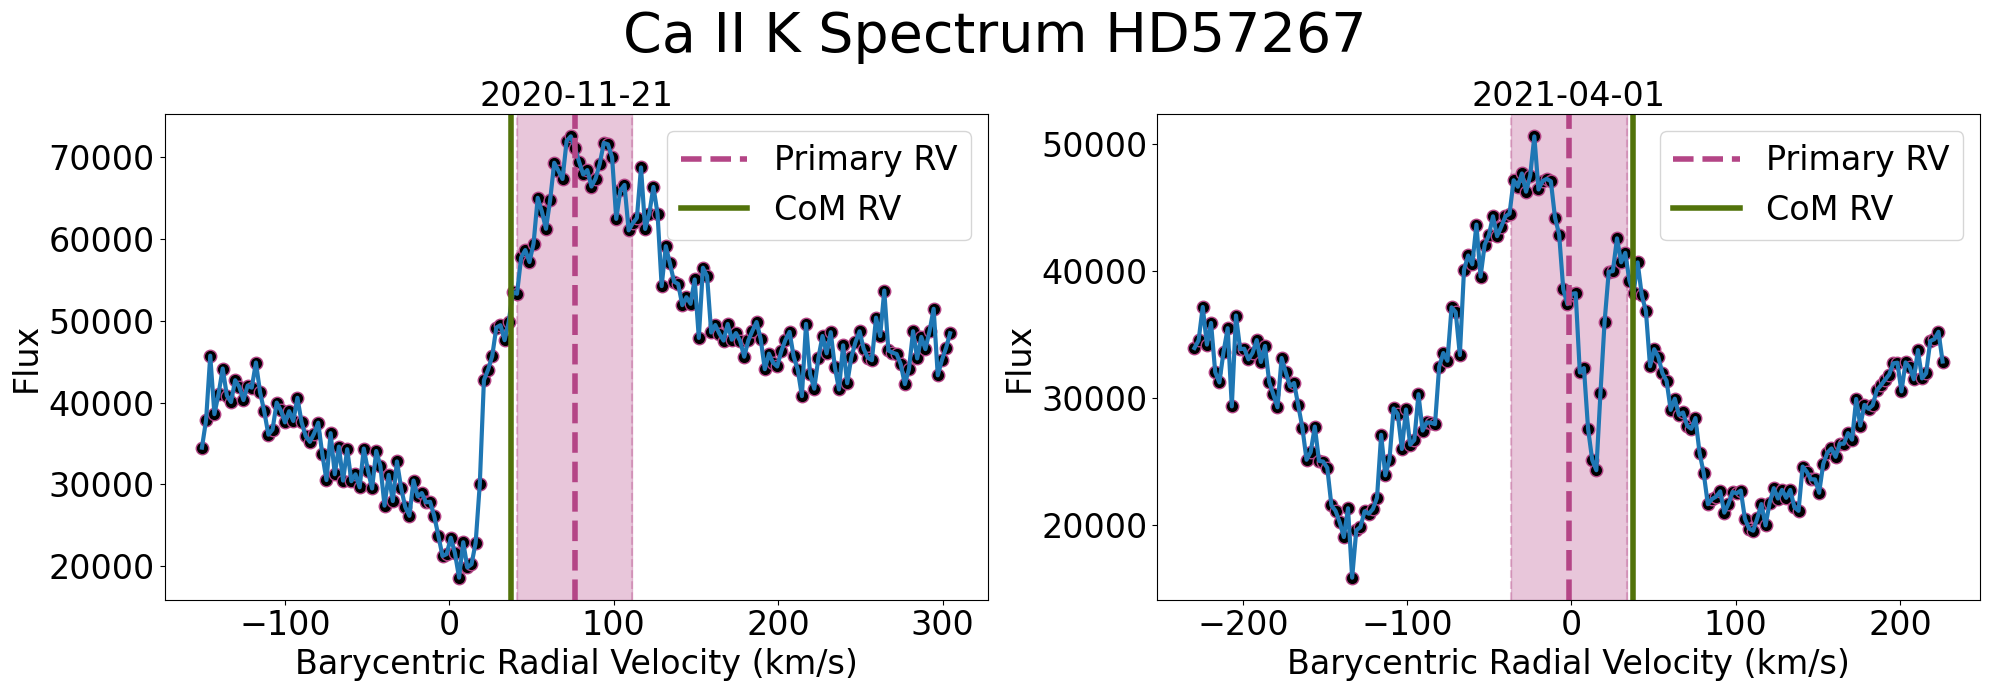

In [51]:
fig3, ax3 = line_autoplot(l_CaK, o_CaK, 'Ca II K', ran = 3)
#fig3.subplots_adjust(top=0.90)

# Hydrogen Beta, Gamma, Delta

0 0
0 1


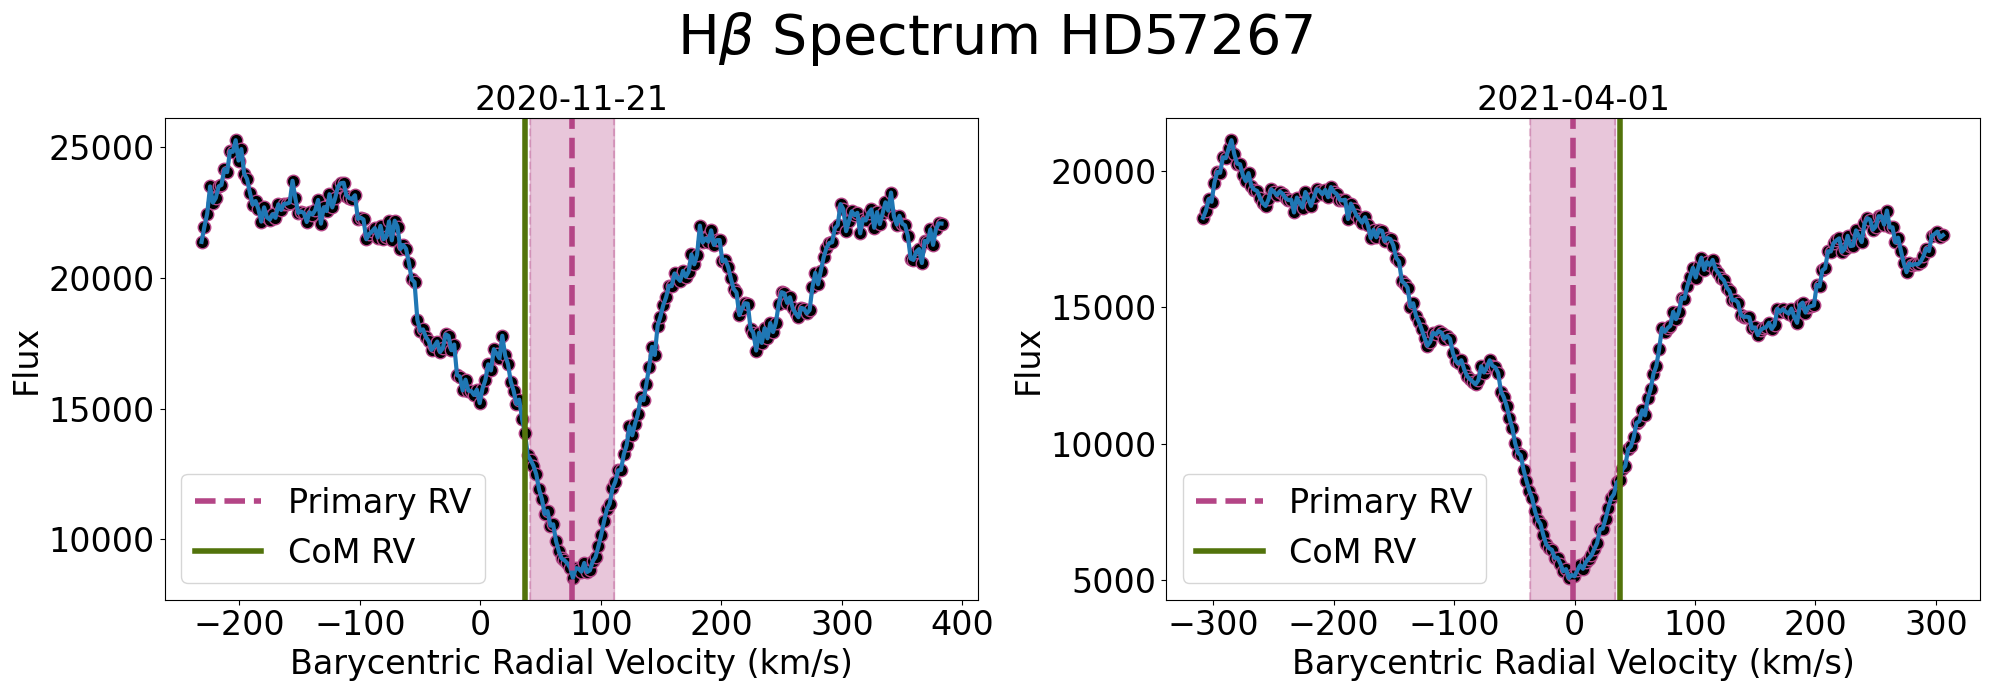

In [52]:
#plotting h_beta:
fig4, ax4 = line_autoplot(l_hb, o_hb, 'H' + r'$\beta$')
#fig4.subplots_adjust(top=0.93)

0 0
0 1


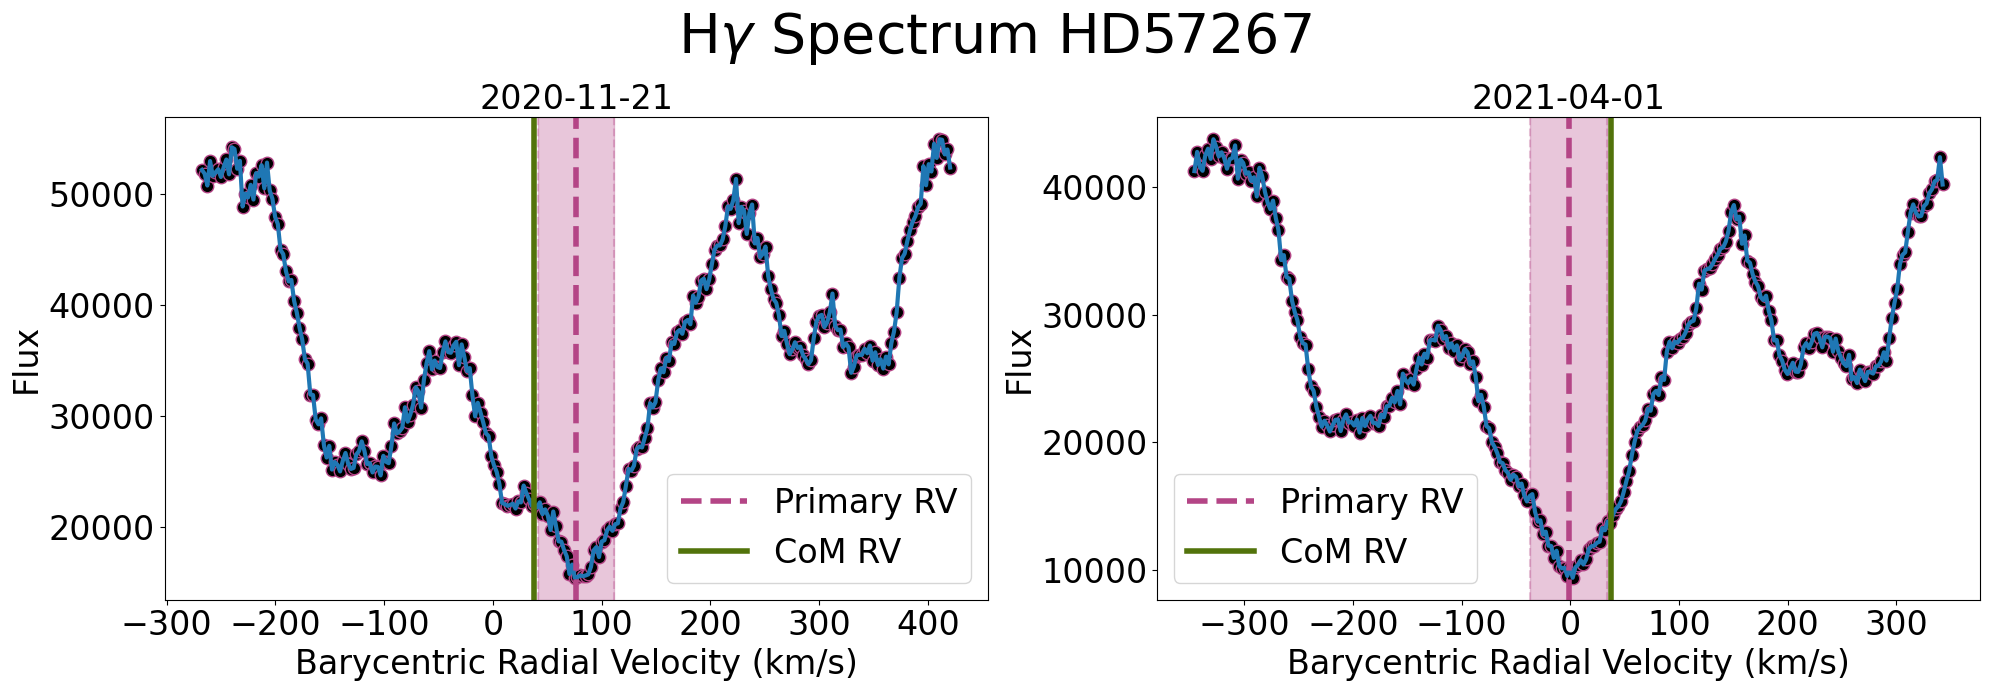

In [53]:
#plotting H-Gamma
fig5, ax5 = line_autoplot(l_hy, o_hy, 'H' + r'$\gamma$')
#fig5.subplots_adjust(top=0.93)

0 0
0 1


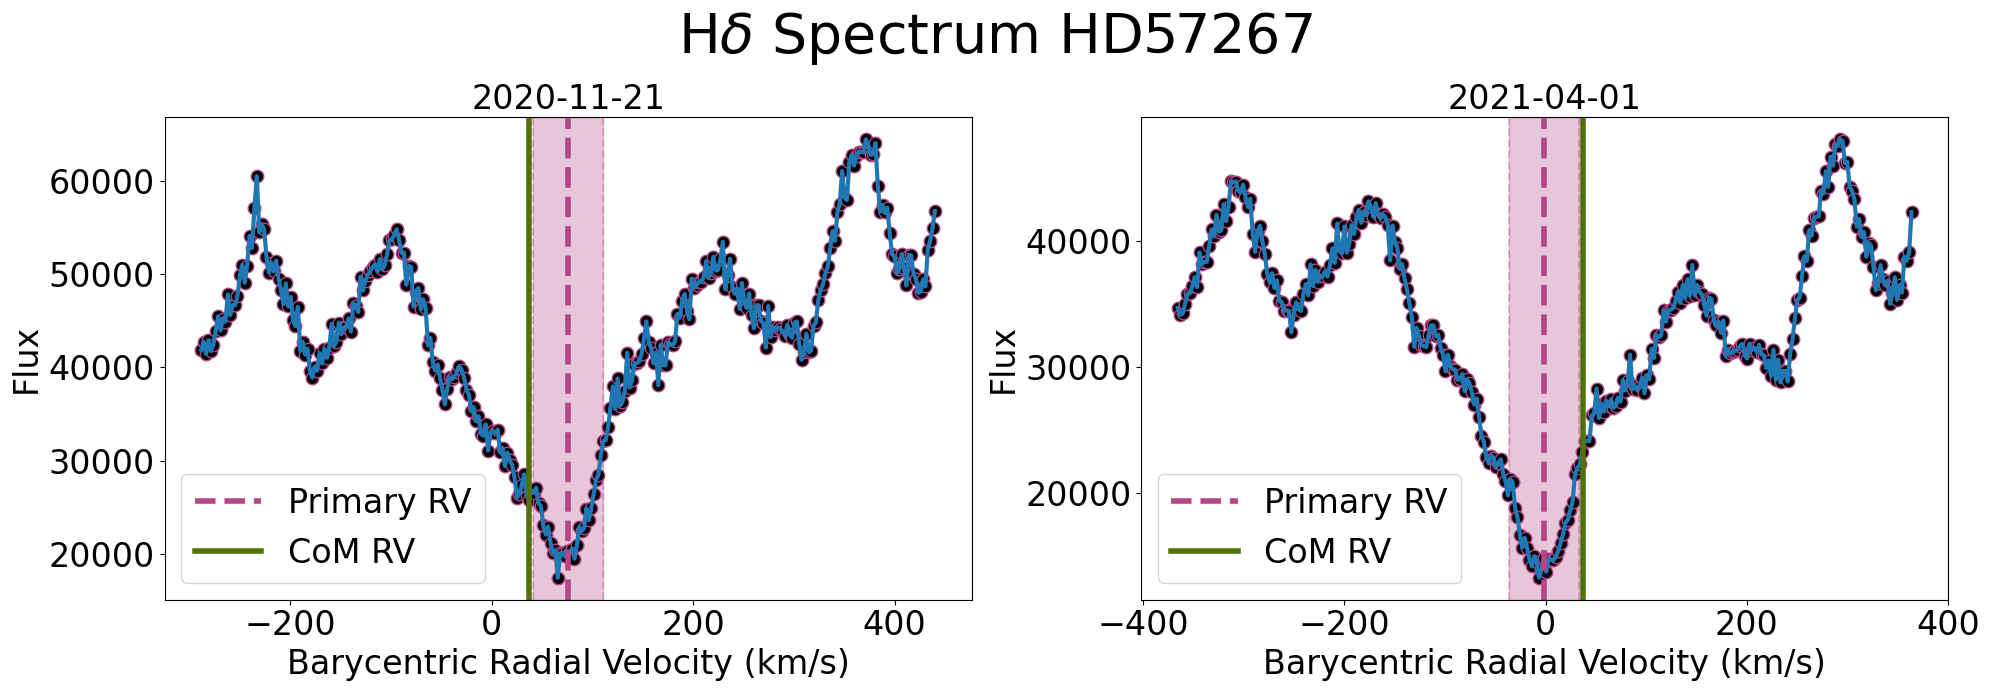

In [54]:
#H-delta
fig6, ax6 = line_autoplot(l_Hd, o_Hd, 'H' + r'$\delta$')
#fig6.subplots_adjust(top=0.93)
#ax6[0,1].set_ylim(top=9000)

# Other Lines

For Other Lines Look Here: https://bass2000.obspm.fr/solar_spect.php

Other Fraunhofer Lines: https://en.wikipedia.org/wiki/Fraunhofer_lines

In [55]:
#line_autoplot(l_O2Z, o_O2Z, 'O II (Z)', 5)

# Save Your Images Here

In [56]:
ha_image = image_path + 'H-alpha\H-alpha_' + star + '.png'
CaH_image = image_path + 'CaII_H\CaH_' + star + '.png'
CaK_image = image_path + 'CaII_K\CaK_' + star + '.png'
hb_image = image_path + 'H-beta\H-beta_' + star + '.png'
hy_image = image_path + 'H-gamma\H-gamma_' + star + '.png'
hDel_image = image_path + 'H-delta\H-delta_' + star + '.png'

In [57]:
fig1.savefig(ha_image)
fig2.savefig(CaH_image)
fig3.savefig(CaK_image)
fig4.savefig(hb_image)
fig5.savefig(hy_image)
fig6.savefig(hDel_image)